# CogniNPC — Test 1: Benchmark wydajnosci i opoznien

 Wersja przeznaczona do generowania wynikow koncowych do pracy magisterskiej.

 **Zmienne niezalezne:** rozmiar modelu, wielkosc kontekstu RAG (k), wspolbieznosc (N)

 **Zmienne zalezne:** TTFT (stan ustalony i zimny start), TPS, czas calkowity,
 narzut orkiestracji, szczytowe zuzycie VRAM

 **Protokol:** rozgrzewka per warunek -> 30 powtorzen -> zapis surowych danych
 do JSONL -> analiza offline. Rozdzielenie zbierania od analizy pozwala
 przeliczac statystyki bez powtarzania kilkugodzinnego przebiegu.


In [ ]:
import json
import platform
import statistics
import subprocess
import threading
import time
import uuid
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timezone
from itertools import product
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats  

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

OUT = Path("results")
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)

API_URL = "http://localhost:8000/api/chat"
OLLAMA_URL = "http://localhost:11434"

NPC_IDS = ["thorin_01", "elara_01"]

SEND_MODEL_PARAM = True
SEND_RAG_K_PARAM = True

MODEL_NAME = "llama3.1:latest"

RAG_KS = [0, 3, 5, 10, 20] if SEND_RAG_K_PARAM else [None]
CONCURRENCIES = [1, 2, 4]
NUM_PREDICT = 128

# --- Protokol pomiarowy ----------------------------------------------------
REPETITIONS = 30                # minimum 30 dla sensownego p95 i przedzialu ufnosci
WARMUP = 3                      # odrzucane z analizy: eliminuja zimny start
COOLDOWN_S = 0.4                # ogranicza kumulacje ciepla i throttling GPU
TIMEOUT_S = 300.0
MAX_RETRIES = 2

# Prog detekcji przeladowania wag: WZGLEDNY, nie absolutny.
RELOAD_RATIO_THRESHOLD = 3.0
RELOAD_FLOOR_MS = 50.0

# --- Progi interpretacyjne ----------------------------------
# Nielsen (1993) podaje trzy granice: 0,1 s, 1 s oraz 10 s. Wartosc 2000 ms
# NIE pochodzi od Nielsena — jest autorska definicja operacyjna budzetu
# maskowania animacja "NPC formuluje odpowiedz". W tekscie pracy nalezy
# te dwie rzeczy rozdzielic, aby nie przypisywac Nielsenowi progu,
# ktorego nie sformulowal.
T_FLOW_MS = 1000.0      # Nielsen 1993 - granica plynnosci toku myslenia
T_MASKED_MS = 2000.0    # definicja wlasna - akceptowalne przy maskowaniu animacja "NPC mysli"
T_BREAK_MS = 10000.0    # Nielsen 1993 - utrata uwagi uzytkownika

# --- Zestaw promptow --------------------------------------------------------
# Klasa promptu jest wspolzmienna kontrolowana: rotujemy je rownomiernie,
# zeby wynik nie zalezal od jednego szczegolnie latwego zapytania.
TEST_PROMPTS = [
    ("krotki", "Hello."),
    ("tozsamosc", "Who are you and what do you do here?"),
    ("prosba", "Can you forge a magical sword for me?"),
    ("emocjonalny", "What is your opinion on magic and elves? I heard you hate them."),
    ("zlozony", "I need a complete set of steel armor, a shield, and a heavy warhammer. "
                "How much will it cost and how long will it take?"),
]

BACKEND_ERROR_PREFIX = "System error:"

RUN_ID = uuid.uuid4().hex[:12]
#RUN_ID = "08df3ac72878"
RAW_PATH = OUT / f"raw_{RUN_ID}.jsonl"
print(f"run_id = {RUN_ID}\nmodel  = {MODEL_NAME}\nsurowe dane -> {RAW_PATH}")


run_id = 59353776873b
model  = llama3.1:latest
surowe dane -> results/raw_59353776873b.jsonl


 ## 2. Wymagane pola po stronie backendu

 `/api/chat` musi przyjmowac `model`, `rag_k`, `num_predict` oraz
 `skip_memory_write` (patrz patch_schemas.py / patch_npc_service.py /
 patch_router.py / patch_ollama_service.py), a `metrics` w odpowiedzi musi
 zawierac WSZYSTKIE ponizsze klucze — brak ktoregokolwiek cicho zeruje
 odpowiadajaca mu kolumne w analizie zamiast rzucic bledem:

  - `wall_total_ms`           -> czas scienny metody process_chat
  - `orchestration_ms`        -> wielkosc resztowa wg definicji z 5.2.4
  - `stage_rag_ms`            -> etap wyszukiwania wektorowego
  - `stage_prompt_build_ms`   -> etap budowy promptu

  Notebook NIE przelicza juz orchestration_ms samodzielnie — poprzednia
  wersja nadpisywala wartosc backendu inna definicja (wzgledem
  total_duration zamiast sumy trzech skladowych), co rozjezdzalo sie
  z opisem w pracy.

 response_chars w analizie czyta klucz `response_text` z ChatResponse —
 jesli nazwa pola w Twoim schemacie jest inna, zmien w single_request().

## 3. Telemetria VRAM i metadane srodowiska

In [8]:
def nvidia_query(field: str) -> str | None:
    try:
        out = subprocess.check_output(
            ["nvidia-smi", f"--query-gpu={field}", "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL, timeout=5,
        )
        return out.decode().strip().splitlines()[0].strip()
    except Exception:
        return None


class VramSampler:
    """Probkuje zajetosc VRAM w watku tla; raportuje wartosc szczytowa."""

    def __init__(self, interval_s: float = 0.25):
        self.interval_s = interval_s
        self._stop = threading.Event()
        self._thread: threading.Thread | None = None
        self._samples: list[float] = []
        self.available = nvidia_query("memory.used") is not None

    def _loop(self):
        while not self._stop.is_set():
            v = nvidia_query("memory.used")
            if v:
                try:
                    self._samples.append(float(v))
                except ValueError:
                    pass
            self._stop.wait(self.interval_s)

    def start(self):
        if not self.available:
            return
        self._samples = []
        self._stop.clear()
        self._thread = threading.Thread(target=self._loop, daemon=True)
        self._thread.start()

    def stop(self) -> dict:
        if not self.available:
            return {}
        self._stop.set()
        if self._thread:
            self._thread.join(timeout=2.0)
        if not self._samples:
            return {}
        return {
            "vram_peak_mb": round(max(self._samples), 1),
            "vram_mean_mb": round(statistics.fmean(self._samples), 1),
        }


def env_fingerprint() -> dict:
    def sh(cmd):
        try:
            return subprocess.check_output(cmd, stderr=subprocess.DEVNULL, timeout=10).decode().strip()
        except Exception:
            return None

    return {
        "git_commit": sh(["git", "rev-parse", "--short", "HEAD"]),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "gpu_name": nvidia_query("name"),
        "gpu_total_vram_mb": nvidia_query("memory.total"),
        "driver": nvidia_query("driver_version"),
    }


ENV = env_fingerprint()
print(json.dumps(ENV, indent=2, ensure_ascii=False))

# nvidia-smi raportuje zajetosc CALEJ karty, nie procesu. Bez wartosci
# odniesienia liczba w tabeli opisuje stan systemu, a nie koszt systemu
# CogniNPC. Roznica wzgledem baseline jest wielkoscia interpretowalna.
_v0 = nvidia_query("memory.used")
VRAM_BASELINE_MB = float(_v0) if _v0 else None
print(f"\nVRAM zajete przed przebiegiem (baseline): {VRAM_BASELINE_MB} MB")
print("UWAGA: uruchom te komorke PRZED zaladowaniem modelu do VRAM,")
print("       inaczej baseline bedzie juz zawieral wagi modelu.")

{
  "git_commit": "73a26e0",
  "python": "3.13.9",
  "platform": "Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35",
  "gpu_name": "NVIDIA GeForce RTX 5070 Ti",
  "gpu_total_vram_mb": "16303",
  "driver": "610.74"
}

VRAM zajete przed przebiegiem (baseline): 2101.0 MB
UWAGA: uruchom te komorke PRZED zaladowaniem modelu do VRAM,
       inaczej baseline bedzie juz zawieral wagi modelu.


 ## 3.5 Zasilenie bazy wiedzy (Database Seeding)
 Uruchom tę komórkę tylko RAZ przed rozpoczęciem testów, aby wypełnić bazę 
 wektorową ChromaDB. Zapewnia to, że przy zapytaniach z rag_k=20 algorytm 
 faktycznie znajdzie i zwróci 20 wspomnień, odpowiednio wydłużając prompt.

In [9]:
# import httpx
# import time

# INJECT_URL = "http://localhost:8000/api/injectMemory" # Dostosuj prefix /api/ do swojego routera

# # Przygotowanie kontekstowych wspomnień
# MEMORIES = [
#     {"npc_id": "thorin_01", "fact": "My name is Thorin, and I am the master blacksmith of the Iron Fortress.", "source": "background"},
#     {"npc_id": "thorin_01", "fact": "I forge weapons and armor for the local guard and passing travelers.", "source": "background"},
#     {"npc_id": "thorin_01", "fact": "I absolutely despise elves. They are arrogant and have no respect for honest, hard work.", "source": "dialogue"},
#     {"npc_id": "thorin_01", "fact": "Magic is just a shortcut for lazy people who are afraid to get their hands dirty with coal.", "source": "dialogue"},
#     {"npc_id": "thorin_01", "fact": "Elves rely on cheap spells because their fragile hands couldn't even lift a real blacksmith's hammer.", "source": "dialogue"},
#     {"npc_id": "thorin_01", "fact": "A complete set of steel armor will cost you exactly 500 gold pieces. Not a copper less.", "source": "trade"},
#     {"npc_id": "thorin_01", "fact": "Forging a full plate armor set with a helmet takes me exactly two weeks of heavy work.", "source": "trade"},
#     {"npc_id": "thorin_01", "fact": "A heavy steel warhammer costs 120 gold pieces and takes three days to forge.", "source": "trade"},
#     {"npc_id": "thorin_01", "fact": "A solid iron-banded shield will set you back 80 gold pieces. I have a few ready right now.", "source": "trade"},
#     {"npc_id": "thorin_01", "fact": "I once tried to forge a magical sword, but the volatile spell shattered my perfect steel.", "source": "event"},
#     {"npc_id": "thorin_01", "fact": "I do not take orders for magical weapons. I work only with pure iron, steel, and dwarven runes.", "source": "trade"},
#     {"npc_id": "thorin_01", "fact": "I heard a rumor that the elves from the Northern Forest are trying to ban mining in our mountains again.", "source": "rumor"},
#     {"npc_id": "thorin_01", "fact": "The finest steel comes from the Deep Shafts, but goblins have infested the lower levels recently.", "source": "world"},
#     {"npc_id": "thorin_01", "fact": "If anyone asks me for a discount on armor, I send them to the cheap amateurs in the Lower City.", "source": "personality"},
#     {"npc_id": "thorin_01", "fact": "My grandfather died in the Great Elven War, and I will never forgive them for what they did to my kin.", "source": "background"},
#     {"npc_id": "thorin_01", "fact": "True power lies in the resilience of tempered steel, not in cheap illusions woven by mages.", "source": "dialogue"},
#     {"npc_id": "thorin_01", "fact": "Forging a magical weapon requires an elven enchanter, and I refuse to cooperate with their kind.", "source": "trade"},
#     {"npc_id": "thorin_01", "fact": "Just yesterday, I threw a mage out of my forge because he wanted me to fix his glowing staff.", "source": "event"},
#     {"npc_id": "thorin_01", "fact": "I only use the highest quality mountain coal to fire my forge for steel armors.", "source": "trade"},
#     {"npc_id": "thorin_01", "fact": "Steel must be properly quenched in oil, otherwise it becomes as brittle as winter ice.", "source": "crafting"},
#     {"npc_id": "thorin_01", "fact": "A heavy warhammer is much better than a sword against plate armor. It crushes bones beneath the steel.", "source": "combat"},
#     {"npc_id": "thorin_01", "fact": "I care little for kingdom politics, as long as the mines keep delivering good ore.", "source": "dialogue"},
#     {"npc_id": "thorin_01", "fact": "Iron supplies are running low due to the eastern war, so the prices of my armor sets are going up.", "source": "economy"},
#     {"npc_id": "thorin_01", "fact": "A steel armor, a sturdy shield, and a heavy warhammer is the absolute best set for surviving melee combat.", "source": "combat"},
#     {"npc_id": "thorin_01", "fact": "All my crafted gear bears the signature of an anvil with a fire rune. It is a mark of supreme quality.", "source": "crafting"},

#     {"npc_id": "elara_01", "fact": "I am Elara, the Archmage of the Silver Leaf Tower.", "source": "background"},
#     {"npc_id": "elara_01", "fact": "I study ancient artifacts and teach young adepts the fine art of spellcasting.", "source": "background"},
#     {"npc_id": "elara_01", "fact": "Dwarves are incredibly annoying, loud, and entirely lack any sense of finesse or elegance.", "source": "dialogue"},
#     {"npc_id": "elara_01", "fact": "I believe magic is the highest form of art, completely inaccessible to simple, unrefined minds.", "source": "dialogue"},
#     {"npc_id": "elara_01", "fact": "Creating a magical sword requires years of study and rare crystals, not just mindlessly banging a hammer.", "source": "magic"},
#     {"npc_id": "elara_01", "fact": "Magical protective barriers are far lighter and much more effective than heavy, clumsy steel armors.", "source": "combat"},
#     {"npc_id": "elara_01", "fact": "Instead of using a shield and a warhammer, I always prefer casting a devastating fireball from a safe distance.", "source": "combat"},
#     {"npc_id": "elara_01", "fact": "I could never get along with a dwarven blacksmith; they only understand brute force and sweat.", "source": "personality"},
#     {"npc_id": "elara_01", "fact": "A magical enhancement for a mundane weapon costs 800 gold pieces in my tower.", "source": "trade"},
#     {"npc_id": "elara_01", "fact": "Enchanting a weapon properly usually takes me a full week of deep meditation under the moonlight.", "source": "trade"},
#     {"npc_id": "elara_01", "fact": "My magic is deeply rooted in the primal elements and the ancient, sacred runes of my people.", "source": "magic"},
#     {"npc_id": "elara_01", "fact": "I heard a rumor that the city guard is wasting their funds on steel armor from that grumpy dwarf.", "source": "rumor"},
#     {"npc_id": "elara_01", "fact": "My lifespan is vastly longer than that of humans or dwarves; I perceive the world on a different scale.", "source": "background"},
#     {"npc_id": "elara_01", "fact": "Elves are the most noble of all races. We have a natural, innate connection to the world's magical energies.", "source": "dialogue"},
#     {"npc_id": "elara_01", "fact": "Yesterday, I undertook an astral projection journey to investigate disturbances in the magical leylines.", "source": "event"},
#     {"npc_id": "elara_01", "fact": "If you are looking for warrior's gear, you have come to the wrong place. We study the mind here, not war.", "source": "dialogue"},
#     {"npc_id": "elara_01", "fact": "I absolutely despise blunt weapons like warhammers. They are primitive, barbaric, and lack precision.", "source": "combat"},
#     {"npc_id": "elara_01", "fact": "Wearing heavy armor only slows down your movements, which is a death sentence during a magical duel.", "source": "combat"},
#     {"npc_id": "elara_01", "fact": "A true magical sword is a rare masterpiece. It requires binding a powerful aura to flawless metal.", "source": "magic"},
#     {"npc_id": "elara_01", "fact": "I know several offensive spells that can easily melt a full set of steel armor in a matter of seconds.", "source": "magic"},
#     {"npc_id": "elara_01", "fact": "Magic is highly dangerous in the hands of fools, which is why access to our libraries must be strictly controlled.", "source": "personality"},
#     {"npc_id": "elara_01", "fact": "I would much rather read ancient, crumbling scrolls than listen to the drunken shouting in the local tavern.", "source": "personality"},
#     {"npc_id": "elara_01", "fact": "I am currently searching for the rare Blue Lotus, which is essential for brewing a powerful healing potion.", "source": "quest"},
#     {"npc_id": "elara_01", "fact": "The most powerful and complex spells demand absolute silence and unwavering focus to cast successfully.", "source": "magic"},
#     {"npc_id": "elara_01", "fact": "I consider dwarven stubbornness to be their ultimate downfall. They never adapt to changing circumstances.", "source": "dialogue"}
# ]

# print(f"Rozpoczynam zasilanie bazy ({len(MEMORIES)} wspomnien)...")
# success_count = 0

# with httpx.Client(timeout=10.0) as client:
#     for mem in MEMORIES:
#         try:
#             r = client.post(INJECT_URL, json=mem)
#             if r.status_code == 200:
#                 success_count += 1
#             else:
#                 print(f"Blad HTTP {r.status_code} dla {mem['npc_id']}")
#         except Exception as e:
#             print(f"Blad sieci: {e}")
#         time.sleep(0.05) # Delikatne opoznienie, aby nie przeciazyc FastAPI/ChromaDB

# print(f"Pomyslnie wstrzyknieto {success_count}/{len(MEMORIES)} wspomnien.")

## 4. Pojedyncze wywolanie i dekompozycja metryk

In [10]:
NS_TO_MS = 1e6

def parse_metrics(m: dict, baseline_load_ms: float | None = None) -> dict:
    """Przelicza natywne liczniki Ollamy (nanosekundy) na milisekundy.

    Rozdzielenie TTFT na wariant zimny i cieply jest istotne metodologicznie:
    `load_duration` jest niezerowe TYLKO gdy nastapilo ladowanie wag do VRAM.
    Wliczanie go do kazdego pomiaru mieszalo by dwa rozne zjawiska —
    jednorazowy koszt startu gry i powtarzalny koszt kazdej wypowiedzi.
    """
    load_ms = m.get("load_duration", 0) / NS_TO_MS
    prefill_ms = m.get("prompt_eval_duration", 0) / NS_TO_MS
    decode_ms = m.get("eval_duration", 0) / NS_TO_MS
    ollama_total_ms = m.get("total_duration", 0) / NS_TO_MS

    prompt_tokens = m.get("prompt_eval_count", 0)
    output_tokens = m.get("eval_count", 0)

    if baseline_load_ms and baseline_load_ms > 0:
        threshold = max(RELOAD_RATIO_THRESHOLD * baseline_load_ms, RELOAD_FLOOR_MS)
    else:
        threshold = RELOAD_FLOOR_MS
    reloaded = load_ms > threshold

    return {
        "llm_error": m.get("error"),
        "load_ms": round(load_ms, 2),
        "model_reloaded": reloaded,
        # Stan ustalony — to odczuwa gracz podczas rozgrywki:
        "ttft_warm_ms": round(prefill_ms, 2),
        # Pierwsza interakcja po uruchomieniu gry:
        "ttft_cold_ms": round(load_ms + prefill_ms, 2),
        "decode_ms": round(decode_ms, 2),
        "ollama_total_ms": round(ollama_total_ms, 2),
        "prompt_tokens": prompt_tokens,
        "output_tokens": output_tokens,
        # Normalizacja dlugosci wypowiedzi. Bez niej porownanie 8B vs 3.8B
        # jest bezwartosciowe: mniejszy model moze po prostu generowac dluzej.
        "tps": round(output_tokens / (decode_ms / 1000), 2) if decode_ms > 0 else None,
        "prefill_tps": round(prompt_tokens / (prefill_ms / 1000), 2) if prefill_ms > 0 else None,

        # Metryki zwrócone przez CogniNPC
        "orchestration_ms": m.get("orchestration_ms"),
        "wall_total_ms":    m.get("wall_total_ms"),
        "stage_rag_ms":     m.get("stage_rag_ms"),
        "stage_prompt_build_ms": m.get("stage_prompt_build_ms"),
        "rag_k_requested": m.get("rag_k_requested"),
        "rag_k_returned": m.get("rag_k_returned"),
    }


def single_request(client: httpx.Client, npc_id: str, prompt: str,
                   model: str, rag_k, prompt_class: str,
                   baseline_load_ms: float | None = None) -> dict:
    payload = {
        "npc_id": npc_id,
        "player_message": prompt,
        "skip_memory_write": True,
        "num_predict": NUM_PREDICT
        }
    if SEND_MODEL_PARAM:
        payload["model"] = model
    if SEND_RAG_K_PARAM and rag_k is not None:
        payload["rag_k"] = rag_k

    last_err = None
    for attempt in range(MAX_RETRIES + 1):
        # perf_counter, nie time.time() — tylko ten pierwszy jest monotoniczny
        # i odporny na korekty zegara systemowego w trakcie dlugiego przebiegu.
        t0 = time.perf_counter()
        try:
            r = client.post(API_URL, json=payload)
            wall_ms = (time.perf_counter() - t0) * 1000
            r.raise_for_status()
            body = r.json()
            rec = {"ok": True, "attempt": attempt, "wall_ms": round(wall_ms, 2)}
            rec.update(parse_metrics(body.get("metrics", {}), baseline_load_ms))

            resp_text = body.get("response_text", "") or ""
            rec["response_chars"] = len(resp_text)

            rec["response_preview"] = resp_text[:150]
            rec["prompt_class"] = prompt_class

            rec["backend_fallback"] = resp_text.startswith(BACKEND_ERROR_PREFIX)

            # Koszt walidacji FastAPI i transportu HTTP, nie modelu. To co jest wykluczone z definicji orchestration_ms w CogniNPC
            if rec.get("wall_total_ms"):
                rec["transport_ms"] = round(wall_ms - rec["wall_total_ms"], 2)
            else:
                rec["transport_ms"] = None
            return rec
        except Exception as exc:
            last_err = f"{type(exc).__name__}: {exc}"
            time.sleep(1.0)

    return {"ok": False, "error": last_err, "prompt_class": prompt_class,
            "attempt": MAX_RETRIES}

## 5. Wykonanie serii wspolbieznej

Ollama serializuje czesc pracy na jednym GPU, wiec latencja przy N=1 nie
mowi nic o scenie, w ktorej rozmawia kilku NPC jednoczesnie. Zakres
ograniczono do N<=4, co odpowiada realistycznej gestosci rownoczesnych
interakcji w scenie RPG przy pojedynczej karcie graficznej.

In [11]:
def run_batch(client: httpx.Client, model: str, rag_k, concurrency: int, rep: int,
              baseline_load_ms: float | None = None) -> list[dict]:
    jobs = []
    for slot in range(concurrency):
        npc_id = NPC_IDS[slot % len(NPC_IDS)]
        cls, prompt = TEST_PROMPTS[(rep + slot) % len(TEST_PROMPTS)]
        jobs.append((npc_id, prompt, cls))

    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=concurrency) as ex:
        futures = [
            ex.submit(single_request, client, npc, pr, model, rag_k, cls, baseline_load_ms)
            for npc, pr, cls in jobs
        ]
        results = [f.result() for f in futures]
    batch_ms = (time.perf_counter() - t0) * 1000

    for slot, rec in enumerate(results):
        rec["slot"] = slot
        # Czas domkniecia calej sceny — dla gracza istotniejszy niz czas
        # pojedynczej odpowiedzi, gdy w tle rozmawia kilku NPC.
        rec["batch_wall_ms"] = round(batch_ms, 2)
    return results

## 6. Glowna petla eksperymentu

Kolejnosc iteracji ustawiona tak, by model zmienial sie najwolniej —
minimalizuje to liczbe przeladowan wag do VRAM.

In [12]:
conditions = [
    {"model": MODEL_NAME, "rag_k": k, "concurrency": c}
    for c, k in product(CONCURRENCIES, RAG_KS)
]
n_requests = sum(c["concurrency"] * (REPETITIONS + WARMUP) for c in conditions)
print(f"Warunkow: {len(conditions)} | Zadan lacznie: ~{n_requests}")

sampler = VramSampler()
if not sampler.available:
    print("UWAGA: nvidia-smi niedostepne — pomiar VRAM zostanie pominiety.")

last_model = None
t_start = time.perf_counter()

with RAW_PATH.open("w", encoding="utf-8") as fh, \
     httpx.Client(timeout=TIMEOUT_S, limits=httpx.Limits(max_connections=32)) as client:

    for ci, cond in enumerate(conditions, 1):
        model, rag_k, conc = cond["model"], cond["rag_k"], cond["concurrency"]

        label = f"{model} | k={rag_k} | N={conc}"
        print(f"[{ci}/{len(conditions)}] {label}", flush=True)

        # Rozgrzewka: absorbuje ladowanie wag i inicjalizacje polaczen HTTP.
        warmup_load_samples = []
        for w in range(WARMUP):
            recs = run_batch(client, model, rag_k, conc, rep=w)
            warmup_load_samples += [r["load_ms"] for r in recs if r.get("ok") and "load_ms" in r]
            time.sleep(COOLDOWN_S)

        baseline_load_ms = (
            statistics.median(warmup_load_samples) if warmup_load_samples else None
        )
        if baseline_load_ms:
            print(f"      baseline load_ms (z rozgrzewki): {baseline_load_ms:.1f}")

        sampler.start()
        for rep in range(REPETITIONS):
            recs = run_batch(client, model, rag_k, conc, rep, baseline_load_ms)
            for rec in recs:
                fh.write(json.dumps({
                    "run_id": RUN_ID,
                    "ts": datetime.now(timezone.utc).isoformat(),
                    "rep": rep,
                    **cond,
                    **rec,
                    **{f"env_{k}": v for k, v in ENV.items()},
                }, ensure_ascii=False) + "\n")
            fh.flush()
            time.sleep(COOLDOWN_S)
        vram = sampler.stop()

        # VRAM przypisujemy do warunku, nie do pojedynczego zadania.
        if vram:
            if VRAM_BASELINE_MB is not None:
                vram["vram_delta_mb"] = round(vram["vram_peak_mb"] - VRAM_BASELINE_MB, 1)
                vram["vram_baseline_mb"] = VRAM_BASELINE_MB
            fh.write(json.dumps({
                "run_id": RUN_ID, "record_type": "vram_summary",
                **cond, **vram,
            }, ensure_ascii=False) + "\n")
            fh.flush()
            print(f"      VRAM szczyt: {vram['vram_peak_mb']:.0f} MB"
                  + (f" (przyrost {vram['vram_delta_mb']:.0f} MB)"
                     if "vram_delta_mb" in vram else ""))

print(f"\nZakonczono w {(time.perf_counter() - t_start)/60:.1f} min -> {RAW_PATH}")

Warunkow: 15 | Zadan lacznie: ~1155
[1/15] llama3.1:latest | k=0 | N=1
      baseline load_ms (z rozgrzewki): 186.7
      VRAM szczyt: 7145 MB (przyrost 5044 MB)
[2/15] llama3.1:latest | k=3 | N=1
      baseline load_ms (z rozgrzewki): 186.6
      VRAM szczyt: 7123 MB (przyrost 5022 MB)
[3/15] llama3.1:latest | k=5 | N=1
      baseline load_ms (z rozgrzewki): 167.5
      VRAM szczyt: 7106 MB (przyrost 5005 MB)
[4/15] llama3.1:latest | k=10 | N=1
      baseline load_ms (z rozgrzewki): 180.7
      VRAM szczyt: 7102 MB (przyrost 5001 MB)
[5/15] llama3.1:latest | k=20 | N=1
      baseline load_ms (z rozgrzewki): 171.8
      VRAM szczyt: 7099 MB (przyrost 4998 MB)
[6/15] llama3.1:latest | k=0 | N=2
      baseline load_ms (z rozgrzewki): 184.8
      VRAM szczyt: 7089 MB (przyrost 4988 MB)
[7/15] llama3.1:latest | k=3 | N=2
      baseline load_ms (z rozgrzewki): 197.3
      VRAM szczyt: 7103 MB (przyrost 5002 MB)
[8/15] llama3.1:latest | k=5 | N=2
      baseline load_ms (z rozgrzewki): 201.5


## ANALIZA

Ponizsza czesc czyta wylacznie plik JSONL — mozna ja uruchamiac dowolnie
wiele razy bez powtarzania benchmarku.

In [13]:
rows = [json.loads(l) for l in RAW_PATH.read_text(encoding="utf-8").splitlines() if l.strip()]
df_all = pd.DataFrame(rows)

vram_df = df_all[df_all.get("record_type") == "vram_summary"] if "record_type" in df_all else pd.DataFrame()
if "record_type" in df_all.columns:
    record_type = df_all["record_type"]
    vram_df = df_all[record_type == "vram_summary"]
    df = df_all[record_type.isna()]
else:
    vram_df = pd.DataFrame()
    df = df_all

n_total = len(df)
df = df[df["ok"] == True].copy()  # noqa: E712
print(f"Rekordow: {n_total} | poprawnych: {len(df)} ({len(df)/max(n_total,1):.1%})")

if n_total - len(df) > 0:
    print("\nRozklad bledow:")
    print(pd.DataFrame(rows).query("ok == False")["error"].value_counts().head())

if "backend_fallback" in df.columns:
    n_fallback = int(df["backend_fallback"].fillna(False).sum())
    if n_fallback:
        print(f"\n!!! {n_fallback} odpowiedzi awaryjnych backendu (HTTP 200, brak generacji):")
        print(df[df["backend_fallback"] == True]["response_preview"].iloc[0])  # noqa: E712
        df = df[df["backend_fallback"] != True].copy()  # noqa: E712
        print(f"    -> odrzucone; pozostalo {len(df)} rekordow")
 
# Kontrola kompletnosci metryk backendu
_missing = [c for c in ["wall_total_ms", "orchestration_ms", "stage_rag_ms"]
            if c not in df.columns or df[c].isna().all()]
if _missing:
    print(f"\n!!! UWAGA: backend nie zwraca pol: {_missing}")
    print("    Dekompozycja czasu bedzie niepelna. Sprawdz instrumentacje w npc_service.py.")
 
if (df["prompt_tokens"] == 0).all():
    print("\n!!! UWAGA: prompt_tokens=0 dla WSZYSTKICH rekordow.")
    print("    Sprawdz, czy backend przekazuje prompt_eval_count w metrics.")
 
# Przeladowania wag to inne zjawisko niz normalna generacja — analizujemy je
# osobno, zamiast pozwolic im zaburzyc mediane stanu ustalonego.
reloads = df[df["model_reloaded"] == True]  # noqa: E712
print(f"\nWykrytych przeladowan modelu w fazie pomiarowej: {len(reloads)}")
if len(reloads):
    print(f"  -> mediana zimnego startu: {reloads['ttft_cold_ms'].median():.0f} ms")
 
df_warm = df[df["model_reloaded"] == False].copy()  # noqa: E712
 
# zabezpieczenie przed pustym df_warm
if df_warm.empty:
    raise RuntimeError(
        "df_warm jest pusty — wszystkie rekordy zaklasyfikowano jako przeladowanie. "
        "Sprawdz RELOAD_FLOOR_MS oraz wartosci load_ms w surowych danych."
    )
print(f"Rekordow w analizie stanu ustalonego: {len(df_warm)}")
 
# Metryka wyprowadzona: rzeczywisty czas oczekiwania w kolejce Ollamy.
# Ollama zwraca total_duration OBEJMUJACE czas oczekiwania na wolny slot
# przetwarzania, natomiast load/prompt_eval/eval_duration mierza WYLACZNIE
# aktywne fazy. Roznica to ograniczenie konfiguracyjne silnika
# (prawdopodobnie OLLAMA_NUM_PARALLEL=1), NIE narzut orkiestracji.
df_warm["ollama_queue_ms"] = (
    df_warm["ollama_total_ms"]
    - (df_warm["load_ms"] + df_warm["ttft_warm_ms"] + df_warm["decode_ms"])
).clip(lower=0)

Rekordow: 1050 | poprawnych: 1050 (100.0%)

Wykrytych przeladowan modelu w fazie pomiarowej: 0
Rekordow w analizie stanu ustalonego: 1050


 ## 7. Kontrola wspolzmiennej: klasa promptu

In [14]:
cov = (df_warm.groupby("prompt_class")
       .agg(n=("wall_ms", "size"),
            ttft_med=("ttft_warm_ms", "median"),
            wall_med=("wall_ms", "median"),
            out_tok_med=("output_tokens", "median"))
       .round(1).reset_index())
display(cov)
 
# Rownomiernosc rozkladu klas w obrebie kazdego warunku
balance = (df_warm.groupby(["rag_k", "concurrency"])["prompt_class"]
           .nunique().reset_index(name="liczba_klas"))
if (balance["liczba_klas"] < len(TEST_PROMPTS)).any():
    print("!!! UWAGA: nie wszystkie klasy promptu wystapily w kazdym warunku.")
    print("    Zwieksz REPETITIONS do wielokrotnosci", len(TEST_PROMPTS))
    display(balance[balance["liczba_klas"] < len(TEST_PROMPTS)])
else:
    print(f"OK: wszystkie {len(TEST_PROMPTS)} klas promptu wystapily w kazdym warunku.")

,prompt_class,n,ttft_med,wall_med,out_tok_med
0,emocjonalny,210,9.6,1428.6,61.0
1,krotki,210,14.3,1145.4,25.5
2,prosba,210,9.7,1102.9,46.0
3,tozsamosc,210,13.3,1159.3,45.0
4,zlozony,210,9.6,1297.8,65.0


OK: wszystkie 5 klas promptu wystapily w kazdym warunku.


## 8. Tabela zbiorcza

In [15]:
def bootstrap_ci_median(x, n_boot=5000, alpha=0.05):
    """Przedzial ufnosci dla mediany metoda percentylowa.

    Rozklady latencji sa prawoskosne, wiec CI oparte na zalozeniu normalnosci
    byloby tu nieuprawnione. Bootstrap nie wymaga zalozen o ksztalcie rozkladu.
    """
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) < 5:
        return (np.nan, np.nan)
    rng = np.random.default_rng(42)
    boots = np.median(rng.choice(x, size=(n_boot, len(x)), replace=True), axis=1)
    return float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


def summarize(df_in: pd.DataFrame) -> pd.DataFrame:
    keys = ["rag_k", "concurrency"]
    out = []
    for name, g in df_in.groupby(keys, dropna=False):
        row = dict(zip(keys, name if isinstance(name, tuple) else (name,)))
        row["n"] = len(g)
        for label, col in [("ttft", "ttft_warm_ms"), ("decode", "decode_ms"),
                           ("wall", "wall_ms"), ("orch", "orchestration_ms"),
                           ("transport", "transport_ms"),
                           ("ollama_queue", "ollama_queue_ms"),
                           ("batch", "batch_wall_ms")]:
            if col not in g:
                continue

            v = g[col].dropna()
            if v.empty:
                continue
            row[f"{label}_med"] = round(v.median(), 1)
            lo, hi = bootstrap_ci_median(v)
            row[f"{label}_ci95"] = f"[{lo:.0f}, {hi:.0f}]"
            row[f"{label}_p95"] = round(np.percentile(v, 95), 1)

        row["tps_med"] = round(df_in.loc[g.index, "tps"].median(), 1)
        row["prompt_tok_med"] = round(g["prompt_tokens"].median(), 0)
        row["out_tok_med"] = round(g["output_tokens"].median(), 0)
        # Operacyjna definicja grywalnosci: odsetek odpowiedzi miesczacych sie
        # w budzecie maskowania animacja.
        row["pct_pod_2s"] = round((g["wall_ms"] < T_MASKED_MS).mean() * 100, 1)
        out.append(row)
    if not out:
        return pd.DataFrame(columns=keys)
    return pd.DataFrame(out).sort_values(keys)


summary = summarize(df_warm)
summary.to_csv(OUT / "tables" / "summary.csv", index=False)
display(summary)

,rag_k,concurrency,n,ttft_med,ttft_ci95,ttft_p95,decode_med,decode_ci95,decode_p95,wall_med,...,ollama_queue_med,ollama_queue_ci95,ollama_queue_p95,batch_med,batch_ci95,batch_p95,tps_med,prompt_tok_med,out_tok_med,pct_pod_2s
0,0,1,30,17.9,"[17, 19]",39.8,345.7,"[325, 471]",720.4,555.5,...,3.7,"[4, 4]",4.2,556.0,"[522, 669]",943.4,113.3,522.0,40.0,100.0
1,0,2,60,18.1,"[17, 19]",49.8,481.1,"[403, 590]",1096.8,1109.4,...,139.0,"[59, 398]",1061.6,1263.4,"[1210, 1362]",1904.0,116.2,524.0,56.0,98.3
2,0,4,120,17.8,"[17, 18]",59.7,493.9,"[438, 540]",941.6,1511.4,...,777.6,"[601, 968]",1793.8,2477.0,"[2401, 2533]",2939.7,117.8,524.0,59.0,70.8
3,3,1,30,54.7,"[10, 55]",62.4,329.1,"[272, 374]",529.1,611.7,...,58.5,"[39, 70]",82.1,612.1,"[573, 681]",857.0,117.7,621.0,39.0,100.0
4,3,2,60,9.6,"[9, 54]",61.9,468.2,"[342, 523]",990.2,1111.5,...,206.9,"[66, 433]",902.6,1317.6,"[1284, 1457]",1781.9,117.8,621.0,52.0,100.0
5,3,4,120,9.2,"[9, 9]",57.5,422.1,"[391, 489]",862.4,1723.9,...,771.6,"[537, 985]",1881.0,2536.6,"[2480, 2585]",2940.6,118.4,621.0,49.0,64.2
6,5,1,30,9.9,"[9, 61]",63.6,312.5,"[233, 362]",508.5,622.0,...,51.5,"[46, 77]",138.1,622.6,"[557, 649]",925.9,118.4,661.0,37.0,100.0
7,5,2,60,9.4,"[9, 10]",62.0,443.2,"[396, 523]",816.1,1136.2,...,185.1,"[68, 400]",841.4,1314.4,"[1288, 1358]",1712.9,117.8,661.0,53.0,100.0
8,5,4,120,9.3,"[9, 10]",62.1,441.0,"[375, 496]",888.8,1696.8,...,816.5,"[556, 1028]",1801.2,2413.6,"[2391, 2463]",2731.5,118.4,661.0,52.0,67.5
9,10,1,30,12.3,"[10, 13]",46.3,311.7,"[250, 367]",540.2,614.3,...,53.4,"[51, 60]",83.7,614.8,"[541, 668]",872.1,117.1,758.0,36.0,100.0


In [16]:
# Tabela VRAM — bezposrednia odpowiedz na pytanie o wykonalnosc sprzetowa.
if not vram_df.empty:
    cols = ["rag_k", "vram_peak_mb"]
    if "vram_delta_mb" in vram_df.columns:
        cols.append("vram_delta_mb")
    vram_tab = (vram_df.groupby("rag_k")[cols[1:]].max().reset_index())
    vram_tab["VRAM szczyt [GB]"] = (vram_tab["vram_peak_mb"] / 1024).round(2)
    vram_tab.to_csv(OUT / "tables" / "vram.csv", index=False)
    display(vram_tab)
    print(f"Karta: {ENV.get('gpu_name')} ({ENV.get('gpu_total_vram_mb')} MB)")
    print("UWAGA: nvidia-smi raportuje zajetosc calej karty. Kolumna")
    print("       vram_delta_mb podaje przyrost wzgledem stanu przed przebiegiem.")

,rag_k,vram_peak_mb,vram_delta_mb,VRAM szczyt [GB]
0,0,7145.0,5044.0,6.98
1,3,7123.0,5022.0,6.96
2,5,7106.0,5005.0,6.94
3,10,7102.0,5001.0,6.94
4,20,7117.0,5016.0,6.95


Karta: NVIDIA GeForce RTX 5070 Ti (16303 MB)
UWAGA: nvidia-smi raportuje zajetosc calej karty. Kolumna
       vram_delta_mb podaje przyrost wzgledem stanu przed przebiegiem.


## 9. Testy istotności statystycznej
  - Kruskal-Wallis: czy poziom k rozniocuje TTFT (>2 grupy)
  - Spearman:       czy zaleznosc k -> TTFT jest monotoniczna
  - Mann-Whitney U: porownania parami dla wspolbieznosci

In [27]:
def epsilon_squared(h_stat: float, n: int, k_groups: int) -> float:
    """Wielkosc efektu dla testu Kruskala-Wallisa."""
    if n - k_groups <= 0:
        return float("nan")
    return (h_stat - k_groups + 1) / (n - k_groups)
 
 
def rank_biserial(u_stat: float, n1: int, n2: int) -> float:
    """Wielkosc efektu dla testu Manna-Whitneya (korelacja rangowo-dwuseryjna)."""
    return 1 - (2 * u_stat) / (n1 * n2)
 
 
def interpret_eps(e: float) -> str:
    if np.isnan(e):
        return "nieokreslona"
    a = abs(e)
    return "mala" if a < 0.06 else ("umiarkowana" if a < 0.14 else "duza")
 
 
def interpret_rb(r: float) -> str:
    a = abs(r)
    return "mala" if a < 0.3 else ("umiarkowana" if a < 0.5 else "duza")
 
 
stat_rows = []

def _scalar_from_stat_result(result, idx: int) -> float:
    if hasattr(result, "statistic") and hasattr(result, "pvalue"):
        value = result.statistic if idx == 0 else result.pvalue
    elif isinstance(result, tuple):
        value = result[idx]
    else:
        value = result
    return float(value)

# --- Efekt 1: wplyw k na TTFT (przy N=1, aby odizolowac od kolejkowania) ---
d_k = df_warm[df_warm["concurrency"] == 1]
groups_k = [g["ttft_warm_ms"].dropna().values
            for _, g in d_k.groupby("rag_k") if len(g) >= 3]
k_levels = sorted(d_k["rag_k"].dropna().unique())
 
if len(groups_k) >= 2:
    h, p = stats.kruskal(*groups_k)
    n_all = sum(len(g) for g in groups_k)
    eps = epsilon_squared(h, n_all, len(groups_k))
    stat_rows.append({
        "efekt": "k -> TTFT (N=1)", "test": "Kruskal-Wallis",
        "statystyka": round(h, 2), "df": len(groups_k) - 1,
        "p": f"{p:.2e}" if p < 1e-3 else round(p, 4),
        "wielkosc_efektu": f"eps^2 = {eps:.3f}",
        "interpretacja": interpret_eps(eps),
        "n": n_all,
    })
 
    spearman_ttft = stats.spearmanr(d_k["rag_k"], d_k["ttft_warm_ms"])
    rho = _scalar_from_stat_result(spearman_ttft, 0)
    p_rho = _scalar_from_stat_result(spearman_ttft, 1)
    stat_rows.append({
        "efekt": "k -> TTFT (monotonicznosc)", "test": "Spearman",
        "statystyka": round(rho, 3), "df": "-",
        "p": f"{p_rho:.2e}" if p_rho < 1e-3 else round(p_rho, 4),
        "wielkosc_efektu": f"rho = {rho:.3f}",
        "interpretacja": interpret_rb(rho),
        "n": len(d_k),
    })
 
    # Mechanizm posredniczacy: k -> dlugosc promptu
    spearman_prompt = stats.spearmanr(d_k["rag_k"], d_k["prompt_tokens"])
    rho_t = _scalar_from_stat_result(spearman_prompt, 0)
    p_t = _scalar_from_stat_result(spearman_prompt, 1)
    stat_rows.append({
        "efekt": "k -> dlugosc promptu", "test": "Spearman",
        "statystyka": round(rho_t, 3), "df": "-",
        "p": f"{p_t:.2e}" if p_t < 1e-3 else round(p_t, 4),
        "wielkosc_efektu": f"rho = {rho_t:.3f}",
        "interpretacja": interpret_rb(rho_t),
        "n": len(d_k),
    })
 
# --- Efekt 2: wplyw wspolbieznosci na czas calkowity ---
mid_k = RAG_KS[len(RAG_KS) // 2]
d_n = df_warm[df_warm["rag_k"] == mid_k] if mid_k is not None else df_warm
 
groups_n = [g["wall_ms"].dropna().values
            for _, g in d_n.groupby("concurrency") if len(g) >= 3]
if len(groups_n) >= 2:
    h, p = stats.kruskal(*groups_n)
    n_all = sum(len(g) for g in groups_n)
    eps = epsilon_squared(h, n_all, len(groups_n))
    stat_rows.append({
        "efekt": f"N -> czas calkowity (k={mid_k})", "test": "Kruskal-Wallis",
        "statystyka": round(h, 2), "df": len(groups_n) - 1,
        "p": f"{p:.2e}" if p < 1e-3 else round(p, 4),
        "wielkosc_efektu": f"eps^2 = {eps:.3f}",
        "interpretacja": interpret_eps(eps),
        "n": n_all,
    })
 
# Porownania parami N=1 vs pozostale
base = d_n[d_n["concurrency"] == 1]["wall_ms"].dropna()
for c in sorted(d_n["concurrency"].unique()):
    if c == 1:
        continue
    other = d_n[d_n["concurrency"] == c]["wall_ms"].dropna()
    if len(base) < 3 or len(other) < 3:
        continue
    u, p = stats.mannwhitneyu(base, other, alternative="two-sided")
    rb = rank_biserial(u, len(base), len(other))
    stat_rows.append({
        "efekt": f"N=1 vs N={c} (czas calkowity)", "test": "Mann-Whitney U",
        "statystyka": round(u, 1), "df": "-",
        "p": f"{p:.2e}" if p < 1e-3 else round(p, 4),
        "wielkosc_efektu": f"r_rb = {rb:.3f}",
        "interpretacja": interpret_rb(rb),
        "n": len(base) + len(other),
    })
 
# --- Efekt 3 (kontrolny): czy narzut orkiestracji zalezy od N? ---
# Oczekiwanie: BRAK istotnej zaleznosci. To potwierdza teze, ze wzrost
# opoznienia przy rosnacym N pochodzi z kolejki silnika, nie z architektury.
if "orchestration_ms" in d_n.columns and d_n["orchestration_ms"].notna().any():
    groups_o = [g["orchestration_ms"].dropna().values
                for _, g in d_n.groupby("concurrency") if g["orchestration_ms"].notna().sum() >= 3]
    if len(groups_o) >= 2:
        h, p = stats.kruskal(*groups_o)
        n_all = sum(len(g) for g in groups_o)
        eps = epsilon_squared(h, n_all, len(groups_o))
        stat_rows.append({
            "efekt": "N -> narzut orkiestracji (kontrolny)", "test": "Kruskal-Wallis",
            "statystyka": round(h, 2), "df": len(groups_o) - 1,
            "p": f"{p:.2e}" if p < 1e-3 else round(p, 4),
            "wielkosc_efektu": f"eps^2 = {eps:.3f}",
            "interpretacja": interpret_eps(eps),
            "n": n_all,
        })
 
stat_tab = pd.DataFrame(stat_rows)
stat_tab.to_csv(OUT / "tables" / "testy_istotnosci.csv", index=False)
display(stat_tab)
 
print("\nUWAGA INTERPRETACYJNA:")
print("Przy n rzedu setek obserwacji nawet roznica pozbawiona znaczenia")
print("praktycznego osiaga p < 0,05. W tekscie pracy nalezy raportowac")
print("wielkosc efektu obok wartosci p i odnosic roznice do progow")
print("percepcyjnych, a nie wylacznie do istotnosci statystycznej.")

,efekt,test,statystyka,df,p,wielkosc_efektu,interpretacja,n
0,k -> TTFT (N=1),Kruskal-Wallis,26.140,4,2.97e-05,eps^2 = 0.153,duza,150
1,k -> TTFT (monotonicznosc),Spearman,-0.412,-,1.67e-07,rho = -0.412,umiarkowana,150
2,k -> dlugosc promptu,Spearman,0.981,-,6.39e-107,rho = 0.981,duza,150
3,N -> czas calkowity (k=5),Kruskal-Wallis,81.170,2,2.36e-18,eps^2 = 0.382,duza,210
4,N=1 vs N=2 (czas calkowity),Mann-Whitney U,230.000,-,1.00e-08,r_rb = 0.744,duza,90
5,N=1 vs N=4 (czas calkowity),Mann-Whitney U,167.000,-,1.72e-14,r_rb = 0.907,duza,150
6,N -> narzut orkiestracji (kontrolny),Kruskal-Wallis,67.660,2,2.03e-15,eps^2 = 0.317,duza,210



UWAGA INTERPRETACYJNA:
Przy n rzedu setek obserwacji nawet roznica pozbawiona znaczenia
praktycznego osiaga p < 0,05. W tekscie pracy nalezy raportowac
wielkosc efektu obok wartosci p i odnosic roznice do progow
percepcyjnych, a nie wylacznie do istotnosci statystycznej.


In [28]:
d = df_warm[df_warm["concurrency"] == 1]
print(d.groupby("rag_k")["prefill_tps"].describe()[["min", "50%", "max"]])
print(d.groupby(["rag_k", "rep"])["ttft_warm_ms"].median().unstack().iloc[:, :4])

            min         50%        max
rag_k                                 
0       8332.56   29137.340   33811.41
3       9897.98   11351.805   80319.28
5      10205.51   68090.930   83333.33
10     11480.99   61632.855   97443.51
20     11367.69  106056.470  119648.60
rep      0.0    1.0    2.0    3.0
rag_k                            
0      54.19  17.10  16.09  18.74
3      61.45  55.41  62.44  62.19
5      63.91  64.28   9.38  62.57
10     17.61  13.24  12.53  67.59
20      8.94   8.08   9.26  81.20


In [29]:
d_n = df_warm[df_warm["rag_k"] == mid_k].copy()
d_n["orch_net_ms"] = (d_n["orchestration_ms"] - d_n["ollama_queue_ms"]).clip(lower=0)

groups = [g["orch_net_ms"].dropna().values for _, g in d_n.groupby("concurrency")]
h, pv = stats.kruskal(*groups)
n = sum(len(g) for g in groups)
print(f"H={h:.2f}  p={pv:.2e}  eps^2={epsilon_squared(h, n, len(groups)):.3f}")
print(d_n.groupby("concurrency")["orch_net_ms"].median())

H=80.77  p=2.89e-18  eps^2=0.381
concurrency
1    51.4130
2    56.7480
4    81.0765
Name: orch_net_ms, dtype: float64


In [30]:
print(df_warm[df_warm["concurrency"]==1].groupby("rag_k")["rag_k_returned"].median())

rag_k
0      0.0
3      3.0
5      5.0
10    10.0
20    20.0
Name: rag_k_returned, dtype: float64


## 10. Wykresy

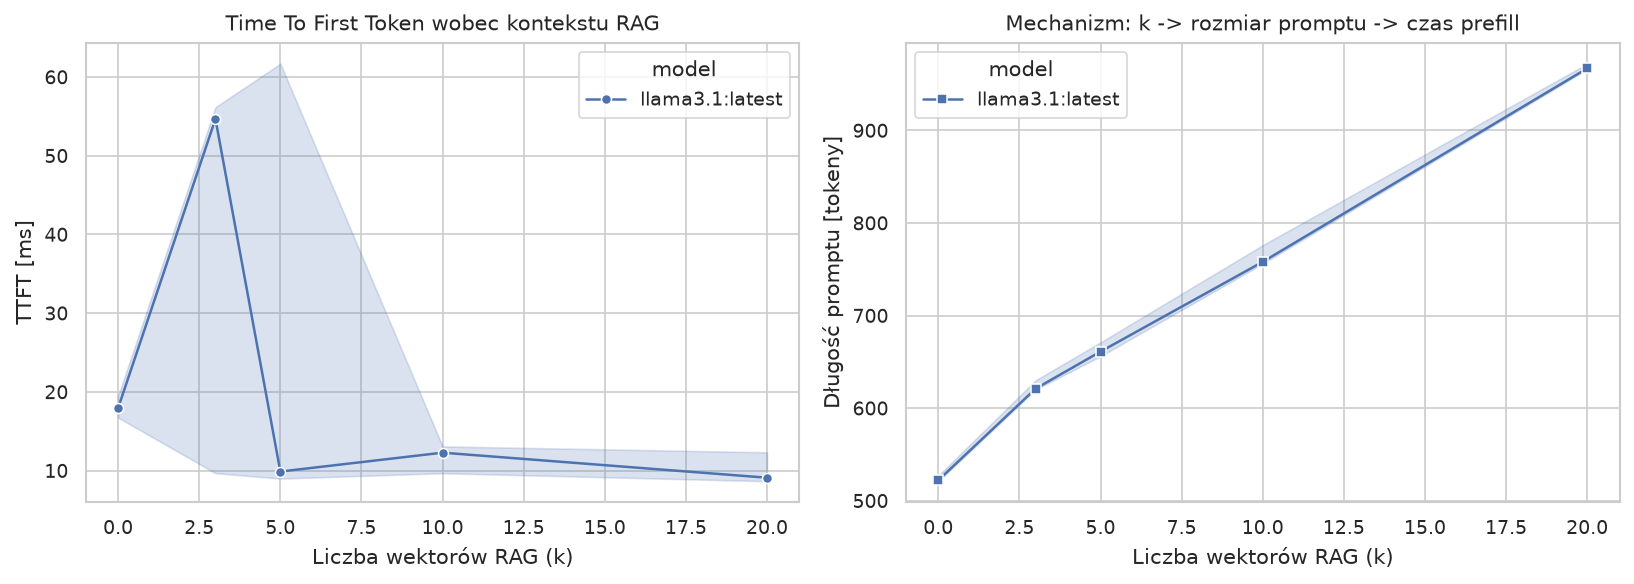

In [18]:
def save_fig(fig, name):
    for ext in ("png", "pdf"):  # PDF = grafika wektorowa do wersji drukowanej
        fig.savefig(OUT / "figures" / f"{name}.{ext}")


# --- Rys. 1: wplyw kontekstu RAG na TTFT + mechanizm ------------------------
if len(RAG_KS) > 1:
    d1 = df_warm[df_warm["concurrency"] == 1]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.lineplot(data=d1, x="rag_k", y="ttft_warm_ms", hue="model", marker="o",
                 estimator="median", errorbar=("pi", 50), ax=axes[0])
    axes[0].set(xlabel="Liczba wektorów RAG (k)", ylabel="TTFT [ms]",
                title="Time To First Token wobec kontekstu RAG")
    sns.lineplot(data=d1, x="rag_k", y="prompt_tokens", hue="model", marker="s",
                 estimator="median", ax=axes[1])
    axes[1].set(xlabel="Liczba wektorów RAG (k)", ylabel="Długość promptu [tokeny]",
                title="Mechanizm: k -> rozmiar promptu -> czas prefill")
    fig.tight_layout()
    save_fig(fig, "rys1_wplyw_rag")
    plt.show()

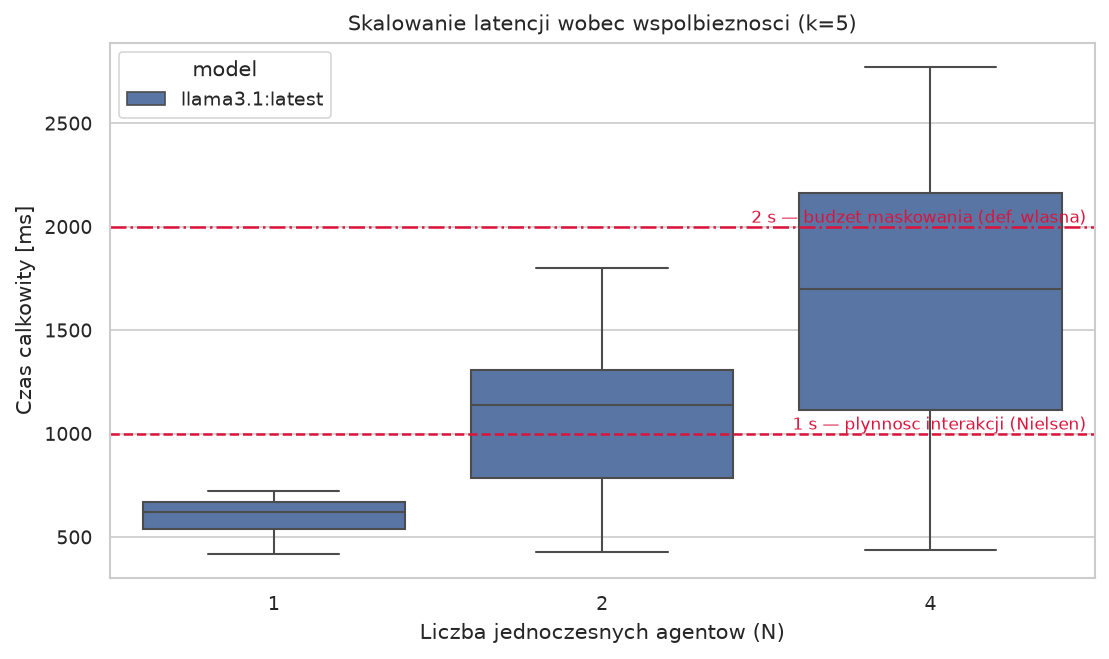

In [ ]:
# --- Rys. 2: skalowanie przy współbieżności --------------------------------
mid_k = RAG_KS[len(RAG_KS) // 2]
d2 = df_warm[df_warm["rag_k"] == mid_k] if mid_k is not None else df_warm

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(data=d2, x="concurrency", y="wall_ms", hue="model", showfliers=False, ax=ax)
for y, lbl, ls in [(T_FLOW_MS, "1 s — płynność interakcji (Nielsen)", "--"),
                   (T_MASKED_MS, "2 s — budżet maskowania (def. własna)", "-.")]:
    ax.axhline(y, ls=ls, lw=1.2, color="crimson")
    ax.text(ax.get_xlim()[1] * 0.99, y, f" {lbl}", va="bottom", ha="right",
            fontsize=8, color="crimson")
ax.set(xlabel="Liczba jednoczesnych agentów (N)", ylabel="Czas całkowity [ms]",
       title=f"Skalowanie latencji wobec współbieżności (k={mid_k})")
fig.tight_layout()
save_fig(fig, "rys6_2_wspolbieznosc")
plt.show()

In [24]:
df_warm["load_ms"].median()

228.775

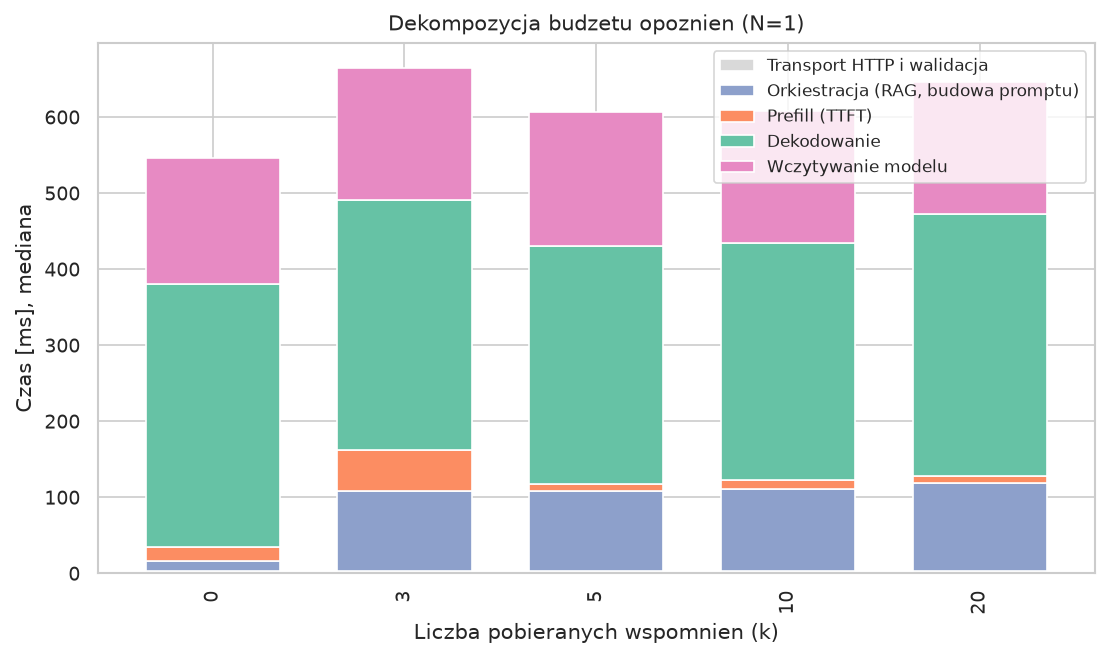

In [31]:
# --- Rys. 3: dekompozycja budzetu opoznien ---------------------------------
# Pokazuje, ile kosztuje Twoj orkiestrator wzgledem samej inferencji.
comp_cols = ["transport_ms", "orchestration_ms", "ttft_warm_ms", "decode_ms", "load_ms"]
comp_cols = [c for c in comp_cols if c in df_warm.columns and df_warm[c].notna().any()]
 
d3 = (df_warm[df_warm["concurrency"] == 1]
      .groupby("rag_k", dropna=False)[comp_cols]
      .median())
 
labels = {"transport_ms": "Transport HTTP i walidacja",
          "orchestration_ms": "Orkiestracja (RAG, budowa promptu)",
          "ttft_warm_ms": "Prefill (TTFT)",
          "decode_ms": "Dekodowanie",
          "load_ms": "Wczytywanie modelu"}
d3.columns = [labels[c] for c in d3.columns]
 
fig, ax = plt.subplots(figsize=(7.5, 4.5))
d3.plot(kind="bar", stacked=True, ax=ax, width=0.7,
        color=["#d9d9d9", "#8da0cb", "#fc8d62", "#66c2a5", "#e78ac3"][-len(d3.columns):])
ax.set(xlabel="Liczba pobieranych wspomnien (k)", ylabel="Czas [ms], mediana",
       title="Dekompozycja budzetu opoznien (N=1)")
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "rys6_3_dekompozycja")
plt.show()

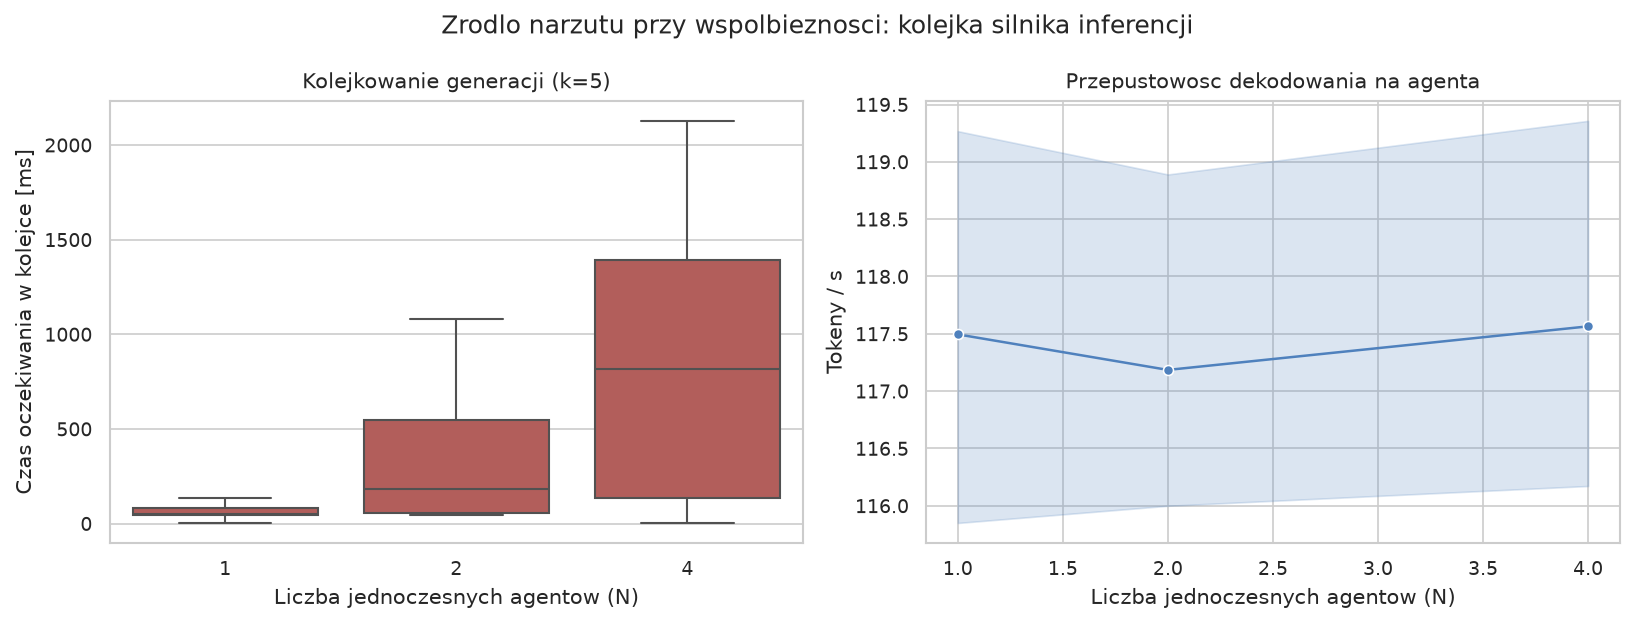

In [21]:
# --- Rys. 4: kolejkowanie Ollamy + spadek przepustowosci -----------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
 
sns.boxplot(data=df_warm[df_warm["rag_k"] == mid_k], x="concurrency",
            y="ollama_queue_ms", showfliers=False, ax=axes[0], color="#c0504d")
axes[0].set(xlabel="Liczba jednoczesnych agentow (N)",
            ylabel="Czas oczekiwania w kolejce [ms]",
            title=f"Kolejkowanie generacji (k={mid_k})")
 
sns.lineplot(data=df_warm, x="concurrency", y="tps", marker="o",
             estimator="median", errorbar=("pi", 50), ax=axes[1], color="#4f81bd")
axes[1].set(xlabel="Liczba jednoczesnych agentow (N)", ylabel="Tokeny / s",
            title="Przepustowosc dekodowania na agenta")
 
fig.suptitle("Zrodlo narzutu przy wspolbieznosci: kolejka silnika inferencji")
fig.tight_layout()
save_fig(fig, "rys6_4_kolejkowanie")
plt.show()

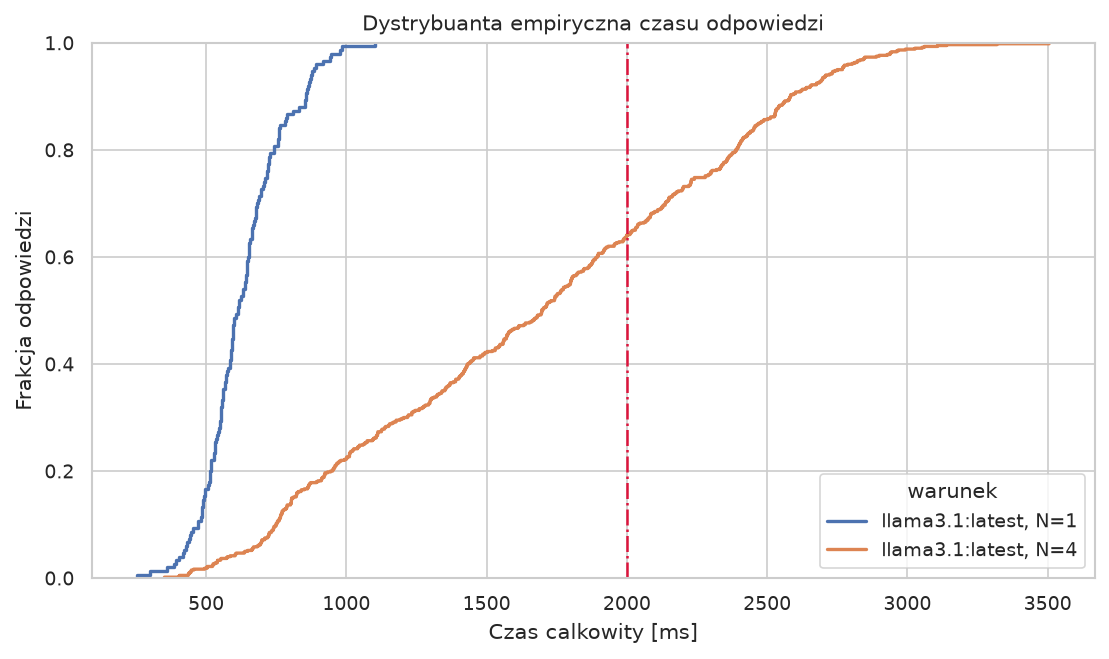

In [22]:
# --- Rys. 5: dystrybuanta empiryczna ---------------------------------------
# Czytelniejsza niz histogram dla ogonow rozkladu — a to ogony decyduja
# o tym, czy gracz odczuje "zacinanie sie" dialogow.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
d4 = df_warm[df_warm["concurrency"].isin([1, max(CONCURRENCIES)])].copy()
d4["warunek"] = d4["model"] + ", N=" + d4["concurrency"].astype(str) # type: ignore
sns.ecdfplot(data=d4, x="wall_ms", hue="warunek", ax=ax, lw=1.6)
ax.axvline(T_MASKED_MS, ls="-.", color="crimson", lw=1.2)
ax.set(xlabel="Czas calkowity [ms]", ylabel="Frakcja odpowiedzi",
       title="Dystrybuanta empiryczna czasu odpowiedzi")
fig.tight_layout()
save_fig(fig, "rys4_dystrybuanta")
plt.show()


## 11. Podsumowanie do rozdzialu wynikow

In [23]:
best = df_warm[df_warm["concurrency"] == 1]
print("=" * 70)
print("PODSUMOWANIE TESTU 1")
print("=" * 70)
print(f"Model:             {MODEL_NAME}")
print(f"Sprzet:            {ENV.get('gpu_name')} / {ENV.get('gpu_total_vram_mb')} MB VRAM")
print(f"Pomiarow:          {len(df_warm)} (po odrzuceniu rozgrzewki i przeladowan)")
print(f"Powtorzen/warunek: {REPETITIONS} | warunkow: {len(conditions)}")
print("-" * 70)
print("STAN USTALONY, N=1:")
print(f"   TTFT                 mediana {best['ttft_warm_ms'].median():7.0f} ms "
      f"| p95 {np.percentile(best['ttft_warm_ms'].dropna(), 95):7.0f} ms")
print(f"   Czas calkowity       mediana {best['wall_ms'].median():7.0f} ms "
      f"| p95 {np.percentile(best['wall_ms'].dropna(), 95):7.0f} ms")
if best["orchestration_ms"].notna().any():
    print(f"   Narzut orkiestracji  mediana {best['orchestration_ms'].median():7.1f} ms")
if best["transport_ms"].notna().any():
    print(f"   Transport i walidacja mediana {best['transport_ms'].median():6.1f} ms")
print(f"   Przepustowosc        mediana {best['tps'].median():7.1f} tok/s")
print(f"   Ponizej 2 s          {(best['wall_ms'] < T_MASKED_MS).mean()*100:7.1f} %")
 
print("-" * 70)
print("WSPOLBIEZNOSC:")
for c in sorted(df_warm["concurrency"].unique()):
    g = df_warm[(df_warm["concurrency"] == c) & (df_warm["rag_k"] == mid_k)]
    if g.empty:
        continue
    print(f"   N={c}: wall {g['wall_ms'].median():6.0f} ms "
          f"| kolejka {g['ollama_queue_ms'].median():6.0f} ms "
          f"| ponizej 2 s {(g['wall_ms'] < T_MASKED_MS).mean()*100:5.1f} %")
 
if len(reloads):
    print("-" * 70)
    print(f"Zimny start (oportunistyczny): mediana {reloads['ttft_cold_ms'].median():.0f} ms")
 
print("=" * 70)
print(f"\nTabele  -> {OUT/'tables'}")
print(f"Wykresy -> {OUT/'figures'}")

PODSUMOWANIE TESTU 1
Model:             llama3.1:latest
Sprzet:            NVIDIA GeForce RTX 5070 Ti / 16303 MB VRAM
Pomiarow:          1050 (po odrzuceniu rozgrzewki i przeladowan)
Powtorzen/warunek: 30 | warunkow: 15
----------------------------------------------------------------------
STAN USTALONY, N=1:
   TTFT                 mediana      13 ms | p95      63 ms
   Czas calkowity       mediana     613 ms | p95     883 ms
   Narzut orkiestracji  mediana   103.1 ms
   Transport i walidacja mediana    2.9 ms
   Przepustowosc        mediana   117.5 tok/s
   Ponizej 2 s            100.0 %
----------------------------------------------------------------------
WSPOLBIEZNOSC:
   N=1: wall    622 ms | kolejka     52 ms | ponizej 2 s 100.0 %
   N=2: wall   1136 ms | kolejka    185 ms | ponizej 2 s 100.0 %
   N=4: wall   1697 ms | kolejka    816 ms | ponizej 2 s  67.5 %

Tabele  -> results/tables
Wykresy -> results/figures
